In [2]:
!pip install prophet

     ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
      --------------------------------------- 0.2/12.1 MB 7.3 MB/s eta 0:00:02
     ----- ---------------------------------- 1.7/12.1 MB 21.4 MB/s eta 0:00:01
     ----------- ---------------------------- 3.5/12.1 MB 28.2 MB/s eta 0:00:01
     ------------------ --------------------- 5.6/12.1 MB 32.4 MB/s eta 0:00:01
     ------------------------- -------------- 7.6/12.1 MB 34.8 MB/s eta 0:00:01
     ------------------------------ --------- 9.4/12.1 MB 35.2 MB/s eta 0:00:01
     ------------------------------------- - 11.6/12.1 MB 43.5 MB/s eta 0:00:01
     --------------------------------------  12.1/12.1 MB 43.7 MB/s eta 0:00:01
     --------------------------------------- 12.1/12.1 MB 36.4 MB/s eta 0:00:00
     ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
     ---------------------------------------- 1.5/1.5 MB 46.6 MB/s eta 0:00:00
     ---------------------------------------- 0.0/99.1 kB ?


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
#import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error

random_state=42

plt.style.use("seaborn-v0_8")


Importing plotly failed. Interactive plots will not work.


In [5]:
#read the data

# Read the CSV
df = pd.read_csv('../data/gas_price_2526.csv')

# Parse date column and set index
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date").sort_index()

# Keep only the target column
df = df[["daily price"]]

print(df.head())
print(df.index.min(), "→", df.index.max())


            daily price
date                   
2025-01-19        39.85
2025-01-20        37.21
2025-01-21        37.33
2025-01-22        37.85
2025-01-23        35.70
2025-01-19 00:00:00 → 2026-06-02 00:00:00


C:\Users\sagal\AppData\Local\Temp\ipykernel_28576\2674796368.py:7: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"])


In [6]:
#prepare data for prophet

def prepare_prophet_data(df):
    prophet_df = df.copy()
    prophet_df = prophet_df.reset_index()
    prophet_df.rename(columns={"date": "ds", "daily price": "y"}, inplace=True)
    return prophet_df

prophet_df = prepare_prophet_data(df)
prophet_df.head()


,ds,y
0,2025-01-19,39.85
1,2025-01-20,37.21
2,2025-01-21,37.33
3,2025-01-22,37.85
4,2025-01-23,35.70


In [7]:
#train and test split

def split_prophet_data(prophet_df, train_ratio=0.80):
    n = len(prophet_df)
    split_idx = int(n * train_ratio)

    train_df = prophet_df.iloc[:split_idx].copy()
    test_df  = prophet_df.iloc[split_idx:].copy()

    print(f"Total rows:   {n}")
    print(f"Train rows:   {len(train_df)}")
    print(f"Test rows:    {len(test_df)}")
    print(f"Train range:  {train_df['ds'].min().date()} → {train_df['ds'].max().date()}")
    print(f"Test range:   {test_df['ds'].min().date()} → {test_df['ds'].max().date()}")

    return train_df, test_df

train_df, test_df = split_prophet_data(prophet_df)


Total rows:   500
Train rows:   400
Test rows:    100
Train range:  2025-01-19 → 2026-02-22
Test range:   2026-02-23 → 2026-06-02


In [8]:
#build prophet model

def build_prophet_model():
    model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False
    )
    return model

prophet_model = build_prophet_model()


In [9]:
#fit on training data

def fit_prophet(model, train_df):
    model.fit(train_df)
    print("Prophet model fitted on training data.")
    return model

prophet_model = fit_prophet(prophet_model, train_df)


20:41:25 - cmdstanpy - INFO - Chain [1] start processing
20:41:28 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted on training data.


In [10]:
#

def forecast_on_test(model, test_df):
    future = test_df[["ds"]].copy()
    forecast = model.predict(future)

    # Keep only relevant columns
    forecast = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]]
    return forecast

test_forecast = forecast_on_test(prophet_model, test_df)
test_forecast.head()


,ds,yhat,yhat_lower,yhat_upper
0,2026-02-23,57.448700,53.116968,61.637949
1,2026-02-24,57.351330,53.026220,61.886525
2,2026-02-25,57.253961,53.147640,61.665045
3,2026-02-26,57.156591,52.986037,61.329546
4,2026-02-27,57.059221,52.803216,61.191462


In [12]:
#evaluate on test set

def evaluate_prophet(test_df, forecast_df):
    # Align actual and forecast
    merged = test_df.merge(forecast_df, on="ds", how="inner")

    y_true = merged["y"].values
    y_pred = merged["yhat"].values

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.2f}%")

    return rmse, mae, mape

rmse, mae, mape = evaluate_prophet(test_df, test_forecast)


RMSE: 22.1884
MAE:  18.3465
MAPE: 23.85%


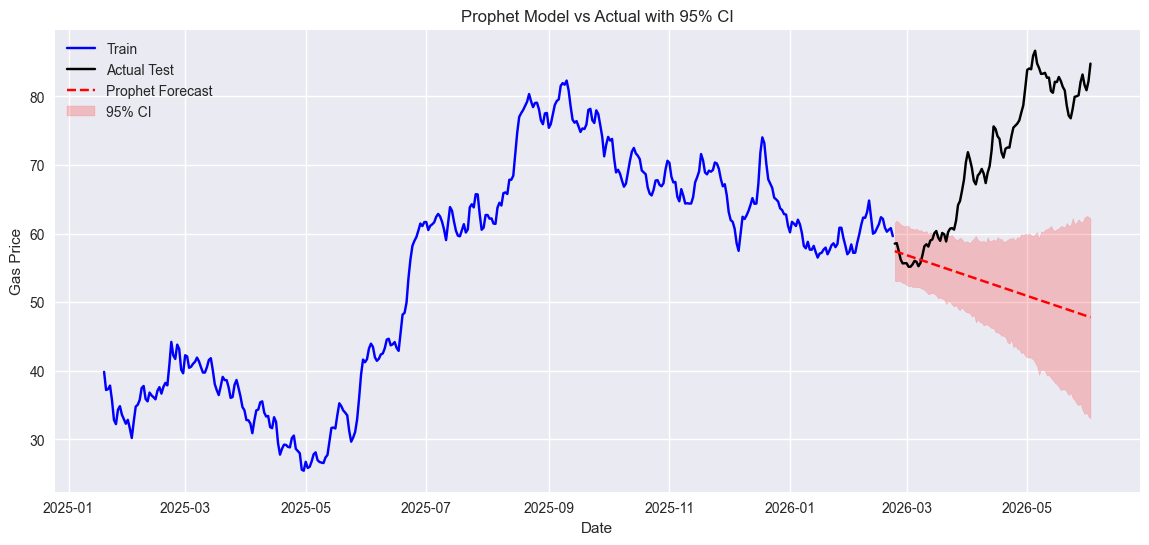

In [13]:
#plot results

def plot_prophet_results(train_df, test_df, forecast_df):
    merged = test_df.merge(forecast_df, on="ds", how="inner")

    plt.figure(figsize=(14,6))

    # Train (blue)
    plt.plot(train_df["ds"], train_df["y"], label="Train", color="blue")

    # Actual Test (black)
    plt.plot(test_df["ds"], test_df["y"], label="Actual Test", color="black")

    # Prophet forecast (red dashed)
    plt.plot(merged["ds"], merged["yhat"], label="Prophet Forecast", color="red", linestyle="--")

    # Confidence interval (red shaded)
    plt.fill_between(
        merged["ds"],
        merged["yhat_lower"],
        merged["yhat_upper"],
        color="red",
        alpha=0.2,
        label="95% CI"
    )

    plt.title("Prophet Model vs Actual with 95% CI")
    plt.xlabel("Date")
    plt.ylabel("Gas Price")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_prophet_results(train_df, test_df, test_forecast)


In [ ]:
#24 month forecast periods

def forecast_future(model, periods=730, freq="D"):
    future = model.make_future_dataframe(periods=periods, freq=freq)
    forecast = model.predict(future)
    forecast = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]]
    return forecast

future_forecast = forecast_future(prophet_model, periods=730)
future_forecast.tail()


,ds,yhat,yhat_lower,yhat_upper
1125,2028-02-18,-13.144363,-329.706273,302.404588
1126,2028-02-19,-13.241733,-329.035289,304.949534
1127,2028-02-20,-13.339103,-331.058242,304.203805
1128,2028-02-21,-13.436473,-334.455417,303.731759
1129,2028-02-22,-13.533842,-334.668420,306.284771


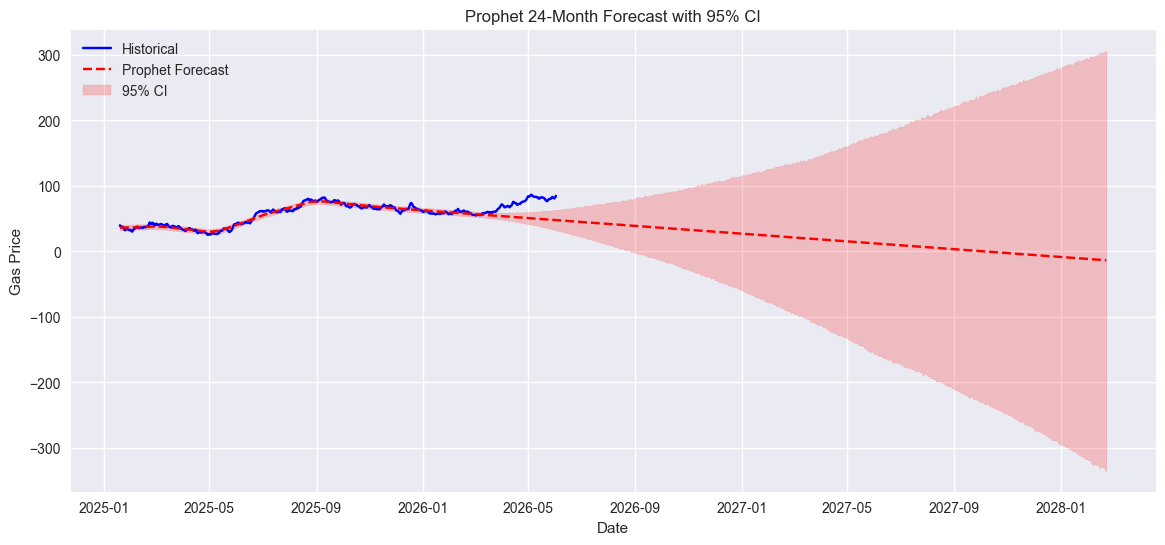

In [15]:
#full plot

def plot_future_forecast(prophet_df, forecast_df):
    plt.figure(figsize=(14,6))

    # Historical data
    plt.plot(prophet_df["ds"], prophet_df["y"], label="Historical", color="blue")

    # Forecast
    plt.plot(forecast_df["ds"], forecast_df["yhat"], label="Prophet Forecast", color="red", linestyle="--")

    # CI
    plt.fill_between(
        forecast_df["ds"],
        forecast_df["yhat_lower"],
        forecast_df["yhat_upper"],
        color="red",
        alpha=0.2,
        label="95% CI"
    )

    plt.title("Prophet 24-Month Forecast with 95% CI")
    plt.xlabel("Date")
    plt.ylabel("Gas Price")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_future_forecast(prophet_df, future_forecast)
